In [1]:
import re
import pandas as pd

In [2]:
f = open('whatsapp_test.txt.txt','r',encoding='utf-8')

In [3]:
data = f.read()

In [4]:
print(data)

19/07/2019, 16:16 - Messages and calls are end-to-end encrypted. No one outside of this chat, not even WhatsApp, can read or listen to them. Tap to learn more.
19/07/2019, 16:16 - You created group "CampusX Mentorship Prog."
19/07/2019, 16:19 - You added CXM6 Sonali Shaw
19/07/2019, 16:20 - You added cxm52 Arya Sarkar
19/07/2019, 16:20 - Nitish Singh: Hi all
19/07/2019, 16:21 - Nitish Singh: Welcome to the group
19/07/2019, 16:21 - CXM22 MD SHAKIB MONDAL: 👋
19/07/2019, 16:21 - CXM24 Surabhi Basak: Hello sir
19/07/2019, 16:21 - cxm52 Arya Sarkar: Hi everyone
19/07/2019, 16:21 - Nitish Singh: Kindly confirm your presence for the orientation class to be held on Sunday
19/07/2019, 18:21 - Nitish Singh: @919830192380 @918249151227
19/07/2019, 18:21 - CXM29 Ujjainee De: Sir, will try to be there.
19/07/2019, 18:23 - CXM27 Sushree Siddhiksha: Sir, I will be there
19/07/2019, 18:34 - CXM26 SUDHANSHU SHAH: Sir, I have an interview that day, If it's over by 3pm then i will come though a bit late

In [5]:
pattern = r'\d{1,2}/\d{1,2}/\d{2,4},\s\d{1,2}:\d{2}\s-\s'

In [6]:
messages = re.split(pattern, data)[1:]
len(messages)

46

In [7]:
dates = re.findall(pattern, data)
dates

['19/07/2019, 16:16 - ',
 '19/07/2019, 16:16 - ',
 '19/07/2019, 16:19 - ',
 '19/07/2019, 16:20 - ',
 '19/07/2019, 16:20 - ',
 '19/07/2019, 16:21 - ',
 '19/07/2019, 16:21 - ',
 '19/07/2019, 16:21 - ',
 '19/07/2019, 16:21 - ',
 '19/07/2019, 16:21 - ',
 '19/07/2019, 18:21 - ',
 '19/07/2019, 18:21 - ',
 '19/07/2019, 18:23 - ',
 '19/07/2019, 18:34 - ',
 '20/07/2019, 05:29 - ',
 '20/07/2019, 11:11 - ',
 '21/07/2019, 05:27 - ',
 '21/07/2019, 12:07 - ',
 '21/07/2019, 12:07 - ',
 '21/07/2019, 12:14 - ',
 '23/07/2019, 19:04 - ',
 '03/08/2019, 19:48 - ',
 '03/08/2019, 19:59 - ',
 '04/08/2019, 07:06 - ',
 '04/08/2019, 07:06 - ',
 '04/08/2019, 11:35 - ',
 '04/08/2019, 15:03 - ',
 '04/08/2019, 15:13 - ',
 '04/08/2019, 15:12 - ',
 '04/08/2019, 18:32 - ',
 '04/08/2019, 18:33 - ',
 '04/08/2019, 19:20 - ',
 '04/08/2019, 19:31 - ',
 '05/08/2019, 19:25 - ',
 '05/08/2019, 19:25 - ',
 '05/08/2019, 19:26 - ',
 '05/08/2019, 19:26 - ',
 '07/08/2019, 20:00 - ',
 '08/08/2019, 20:00 - ',
 '08/08/2019, 20:04 - ',


In [8]:
df = pd.DataFrame({'user_message':messages, 'message_date': dates})
# convert message_data type
df['message_date'] = pd.to_datetime(df['message_date'],format='%d/%m/%Y, %H:%M - ')

df.rename(columns={'message_date': 'date'}, inplace=True)

df.head()

,user_message,date
0,Messages and calls are end-to-end encrypted. N...,2019-07-19 16:16:00
1,"You created group ""CampusX Mentorship Prog.""\n",2019-07-19 16:16:00
2,You added CXM6 Sonali Shaw\n,2019-07-19 16:19:00
3,You added cxm52 Arya Sarkar\n,2019-07-19 16:20:00
4,Nitish Singh: Hi all\n,2019-07-19 16:20:00


In [9]:
df.shape

(46, 2)

In [10]:
# separate users and messages
users = []
messages =[]
for message in df['user_message']:
    entry = re.split('([w\W]+?):\s',message)
    if entry[1:]:# user name
        users.append(entry[1])
        messages.append(entry[2])
    else:
        users.append('group_notification')
        messages.append(entry[0])

df['users'] = users
df['messages'] = messages
df.drop(columns=['user_message'],inplace=True)

df.head()
    

,date,users,messages
0,2019-07-19 16:16:00,group_notification,Messages and calls are end-to-end encrypted. N...
1,2019-07-19 16:16:00,group_notification,"You created group ""CampusX Mentorship Prog.""\n"
2,2019-07-19 16:19:00,group_notification,You added CXM6 Sonali Shaw\n
3,2019-07-19 16:20:00,group_notification,You added cxm52 Arya Sarkar\n
4,2019-07-19 16:20:00,group_notification,Nitish Singh: Hi all\n


In [11]:
df['year'] = df['date'].dt.year

In [12]:
df.head()

,date,users,messages,year
0,2019-07-19 16:16:00,group_notification,Messages and calls are end-to-end encrypted. N...,2019
1,2019-07-19 16:16:00,group_notification,"You created group ""CampusX Mentorship Prog.""\n",2019
2,2019-07-19 16:19:00,group_notification,You added CXM6 Sonali Shaw\n,2019
3,2019-07-19 16:20:00,group_notification,You added cxm52 Arya Sarkar\n,2019
4,2019-07-19 16:20:00,group_notification,Nitish Singh: Hi all\n,2019


In [13]:
df['month'] = df['date'].dt.month_name()

In [14]:
df['day'] = df['date'].dt.day

In [37]:
df['only_date'] = df['date'].dt.date

In [15]:
df['hour'] = df['date'].dt.hour

In [51]:
df['month_num'] = df['date'].dt.month

In [16]:
df['minute'] = df['date'].dt.minute

In [17]:
df.head()

,date,users,messages,year,month,day,hour,minute
0,2019-07-19 16:16:00,group_notification,Messages and calls are end-to-end encrypted. N...,2019,July,19,16,16
1,2019-07-19 16:16:00,group_notification,"You created group ""CampusX Mentorship Prog.""\n",2019,July,19,16,16
2,2019-07-19 16:19:00,group_notification,You added CXM6 Sonali Shaw\n,2019,July,19,16,19
3,2019-07-19 16:20:00,group_notification,You added cxm52 Arya Sarkar\n,2019,July,19,16,20
4,2019-07-19 16:20:00,group_notification,Nitish Singh: Hi all\n,2019,July,19,16,20


In [18]:
df[df['users'] == 'Nitish Singh'].shape

(0, 8)

In [19]:
words = []
for messages in df['messages']:
    words.extend(messages.split())

In [20]:
len(words)

551

In [21]:
df[df['messages'] == '<Media omitted>\n'].shape[0]

0

In [22]:
print(df)

                  date               users  \
0  2019-07-19 16:16:00  group_notification   
1  2019-07-19 16:16:00  group_notification   
2  2019-07-19 16:19:00  group_notification   
3  2019-07-19 16:20:00  group_notification   
4  2019-07-19 16:20:00  group_notification   
5  2019-07-19 16:21:00  group_notification   
6  2019-07-19 16:21:00  group_notification   
7  2019-07-19 16:21:00  group_notification   
8  2019-07-19 16:21:00  group_notification   
9  2019-07-19 16:21:00  group_notification   
10 2019-07-19 18:21:00  group_notification   
11 2019-07-19 18:21:00  group_notification   
12 2019-07-19 18:23:00  group_notification   
13 2019-07-19 18:34:00  group_notification   
14 2019-07-20 05:29:00  group_notification   
15 2019-07-20 11:11:00  group_notification   
16 2019-07-21 05:27:00  group_notification   
17 2019-07-21 12:07:00  group_notification   
18 2019-07-21 12:07:00  group_notification   
19 2019-07-21 12:14:00  group_notification   
20 2019-07-23 19:04:00  group_noti

In [23]:
pip install urlextract

Note: you may need to restart the kernel to use updated packages.


In [24]:
from urlextract import URLExtract
extractor = URLExtract()

links = []
for message in df['messages']:
    links.extend(extractor.find_urls(message))

In [25]:
print(len(links))
print(links)

2
['https://www.linkedin.com/in/kaushal-agarwal-15b086183', 'https://imjo.in/q5wtdp']


In [26]:
df

,date,users,messages,year,month,day,hour,minute
0,2019-07-19 16:16:00,group_notification,Messages and calls are end-to-end encrypted. N...,2019,July,19,16,16
1,2019-07-19 16:16:00,group_notification,"You created group ""CampusX Mentorship Prog.""\n",2019,July,19,16,16
2,2019-07-19 16:19:00,group_notification,You added CXM6 Sonali Shaw\n,2019,July,19,16,19
3,2019-07-19 16:20:00,group_notification,You added cxm52 Arya Sarkar\n,2019,July,19,16,20
4,2019-07-19 16:20:00,group_notification,Nitish Singh: Hi all\n,2019,July,19,16,20
5,2019-07-19 16:21:00,group_notification,Nitish Singh: Welcome to the group\n,2019,July,19,16,21
6,2019-07-19 16:21:00,group_notification,CXM22 MD SHAKIB MONDAL: 👋\n,2019,July,19,16,21
7,2019-07-19 16:21:00,group_notification,CXM24 Surabhi Basak: Hello sir\n,2019,July,19,16,21
8,2019-07-19 16:21:00,group_notification,cxm52 Arya Sarkar: Hi everyone\n,2019,July,19,16,21
9,2019-07-19 16:21:00,group_notification,Nitish Singh: Kindly confirm your presence for...,2019,July,19,16,21


In [27]:
x = df['users'].value_counts().head()

In [28]:
import matplotlib.pyplot as plt

In [29]:
name = x.index
count = x.values

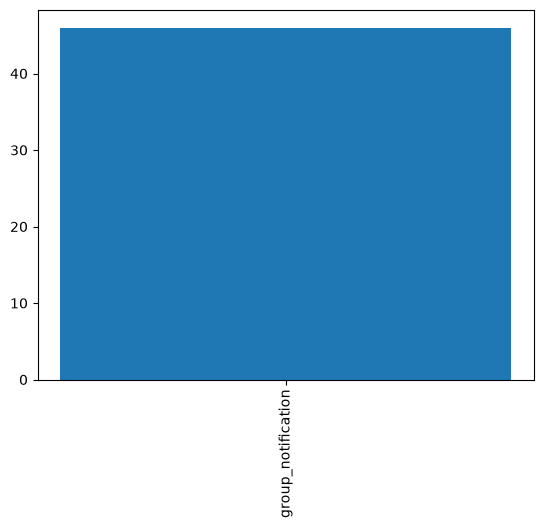

In [30]:
plt.bar(name,count)
plt.xticks(rotation='vertical')
plt.show()

In [31]:
round(df['users'].value_counts()/df.shape[0]*100,2).reset_index().rename(columns={'index':'name','user':'percent'})

,users,count
0,group_notification,100.0


In [32]:
temp = df[df['users'] == 'group_notification']
temp = temp[temp['messages'] != '<Media omitted>\n']

In [33]:
f = open('stop_hinglish.txt.txt','r')
stop_words = f.read()
print(stop_words)

.
..
...
?
-
--
1
2
3
4
5
6
7
8
9
0
a
aadi
aaj
aap
aapne
aata
aati
aaya
aaye
ab
abbe
abbey
abe
abhi
able
about
above
accha
according
accordingly
acha
achcha
across
actually
after
afterwards
again
against
agar
ain
aint
ain't
aisa
aise
aisi
alag
all
allow
allows
almost
alone
along
already
also
although
always
am
among
amongst
an
and
andar
another
any
anybody
anyhow
anyone
anything
anyway
anyways
anywhere
ap
apan
apart
apna
apnaa
apne
apni
appear
are
aren
arent
aren't
around
arre
as
aside
ask
asking
at
aur
avum
aya
aye
baad
baar
bad
bahut
bana
banae
banai
banao
banaya
banaye
banayi
banda
bande
bandi
bane
bani
bas
bata
batao
bc
be
became
because
become
becomes
becoming
been
before
beforehand
behind
being
below
beside
besides
best
better
between
beyond
bhai
bheetar
bhi
bhitar
bht
bilkul
bohot
bol
bola
bole
boli
bolo
bolta
bolte
bolti
both
brief
bro
btw
but
by
came
can
cannot
cant
can't
cause
causes
certain
certainly
chahiye
chaiye
chal
chalega
chhaiye
clearly
c'mon
com
come
comes
could
coul

In [34]:
words = []

for message in temp['messages']:
    for word in message.lower().split():
        if word not in stop_words:
            words.append(word)

In [35]:
from collections import Counter
pd.DataFrame(Counter(words).most_common(20))

,0,1
0,nitish,14
1,singh:,14
2,cxm28,6
3,kunal,6
4,n.,6
5,gohrani:,6
6,group,4
7,mentorship,4
8,orientation,4
9,"sir,",4


In [36]:
# remove group message
# remove media omitted message
# remove stop words

In [40]:
!pip install wordcloud

  Using cached wordcloud-1.9.6-cp314-cp314-win_amd64.whl.metadata (3.5 kB)
Using cached wordcloud-1.9.6-cp314-cp314-win_amd64.whl (308 kB)


  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.


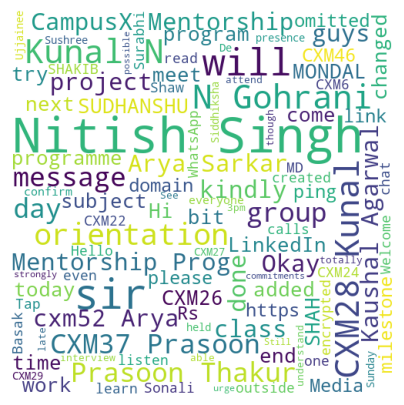

In [41]:
from wordcloud import WordCloud
import matplotlib.pyplot as plt

# स्टॉप वर्ड्स हटाने के बाद टेक्स्ट डेटा तैयार करना
wc = WordCloud(width=500, height=500, min_font_size=10, background_color='white')
text_data = temp['messages'].str.cat(sep=" ")

df_wc = wc.generate(text_data)

plt.figure(figsize=(5,5))
plt.imshow(df_wc)
plt.axis("off")
plt.show()

In [42]:
from collections import Counter

words = []
for message in temp['messages']:
    for word in message.lower().split():
        if word not in stop_words:
            words.append(word)

most_common_df = pd.DataFrame(Counter(words).most_common(20))
most_common_df

,0,1
0,nitish,14
1,singh:,14
2,cxm28,6
3,kunal,6
4,n.,6
5,gohrani:,6
6,group,4
7,mentorship,4
8,orientation,4
9,"sir,",4


In [46]:
!pip install emoji

  Using cached emoji-2.16.0-py3-none-any.whl.metadata (5.7 kB)
Using cached emoji-2.16.0-py3-none-any.whl (610 kB)


In [48]:
import emoji

emojis = []
for message in df['messages']:
    emojis.extend([c for c in message if emoji.is_emoji(c)])

emoji_df = pd.DataFrame(Counter(emojis).most_common(len(Counter(emojis))))
emoji_df.head(10)

,0,1
0,👍,2
1,👋,1
2,🙌,1
3,🔥,1
4,💸,1
5,🙏,1
6,🎯,1


In [52]:
timeline = df.groupby(['year', 'month_num', 'month']).count()['messages'].reset_index()

time = []
for i in range(timeline.shape[0]):
    time.append(timeline['month'][i] + "-" + str(timeline['year'][i]))
    
timeline['time'] = time
timeline

,year,month_num,month,messages,time
0,2019,7,July,21,July-2019
1,2019,8,August,25,August-2019


In [45]:
daily_timeline = df.groupby('only_date').count()['messages'].reset_index()
daily_timeline

,only_date,messages
0,2019-07-19,14
1,2019-07-20,2
2,2019-07-21,4
3,2019-07-23,1
4,2019-08-03,2
5,2019-08-04,10
6,2019-08-05,4
7,2019-08-07,1
8,2019-08-08,8
